# Visualization of Parkinson’s Disease Detection Results

This notebook visualizes the performance of the trained machine learning model using:
- confusion matrix
- ROC curve
- feature importance
- performance metric bar chart

In [1]:
from src.visualizer import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
    plot_metric_bar
)

## 1. Prepare Model Outputs

To generate the plots, the notebook reloads the data preparation and model training steps, then obtains:
- predicted labels
- predicted probabilities
- feature names
- evaluation metrics

In [2]:
from src.data_utils import (
    load_data,
    clean_numeric_data,
    split_and_scale,
    balance_classes
)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

df = load_data(r"D:\Datasets\PD-alldata.csv")
df = clean_numeric_data(df, target_column="status")

X_train, X_test, y_train, y_test, scaler = split_and_scale(
    df,
    target_column="status"
)

X_train_balanced, y_train_balanced = balance_classes(
    X_train,
    y_train,
    method="tomek"
)

feature_names = X_train.columns.tolist()

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_balanced, y_train_balanced)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "MCC": matthews_corrcoef(y_test, y_pred)
}

print("Visualization inputs are ready.")
print(results)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Visualization inputs are ready.
{'Accuracy': 0.9565217391304348, 'Precision': 0.9736842105263158, 'Recall': 0.9736842105263158, 'F1-score': 0.9736842105263158, 'ROC-AUC': 0.9868421052631579, 'MCC': 0.8486842105263158}


## 2. Confusion Matrix and ROC Curve

These plots show:
- how many samples are classified correctly or incorrectly
- how well the model separates positive and negative classes across thresholds

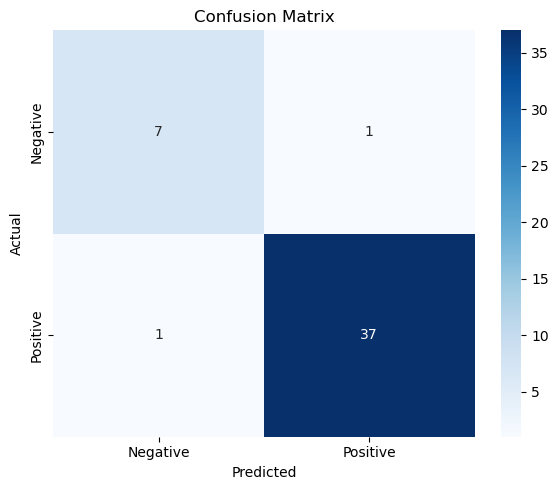

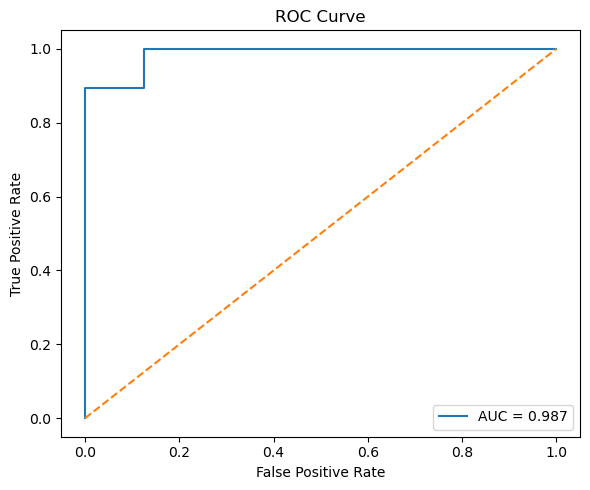

In [3]:
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_proba)

## 3. Feature Importance and Performance Summary

The feature importance plot highlights which biomedical voice features contribute most to the model.  
The metric bar chart provides a compact summary of overall classification performance.

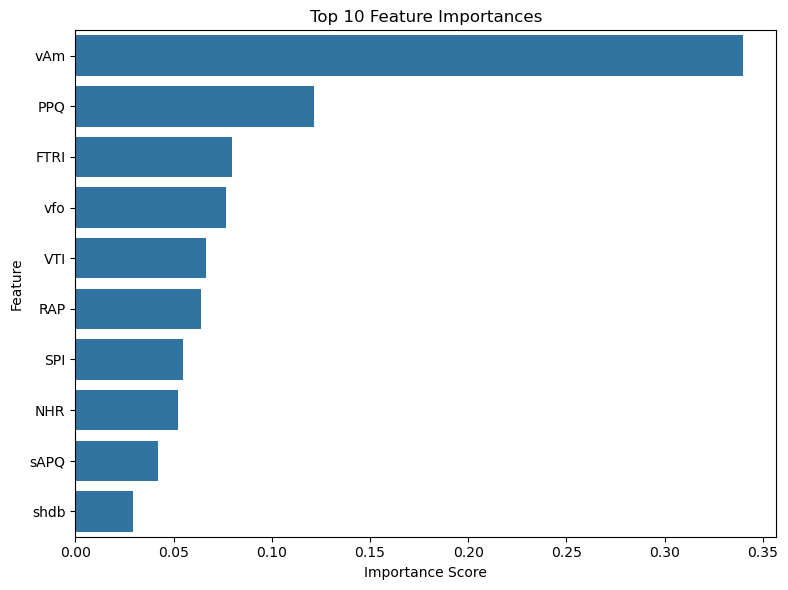

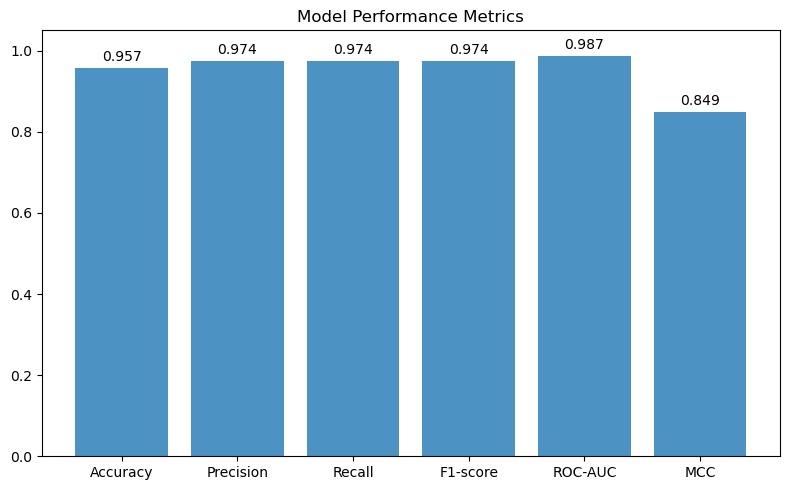

In [4]:
plot_feature_importance(best_model, feature_names, top_n=10)
plot_metric_bar(results)